# IJava Jupyter Kernel - Complete Feature Demo

This notebook demonstrates the full capabilities of the IJava kernel including:
- **Magics consolidation** with `--help` support
- **Shell commands** with configurable timeout and shell selection
- **Java compilation** with annotation processing (Lombok)
- **Maven dependencies** and POM file loading
- **Source code extraction** with regex and selection
- **Database schema visualization** and SQL queries
- **PlantUML diagrams** for documentation
- **Performance timing** for optimization

**New in this version:** All duplicate magics have been consolidated. Deprecated magics now show clear warnings guiding users to the preferred alternatives.

### Class inspection & Javadoc

Quick demos for the new helper magics: `%class-info`, `%javadoc-html`, and `%where`/`%which`.

- `%class-info <FQCN>` : Show constructors, fields, methods and annotations as Markdown.
- `%javadoc-html <FQCN>` : Render the class Javadoc (if available) as HTML for rich display.
- `%where` / `%which <FQCN>` : Show where the class is loaded from and the source path if available.

In [1]:
%class-info com.example.Product

Failed to inspect com.example.Product: com.example.Product


In [2]:
%javadoc-html com.example.Product

No javadoc found for com.example.Product


In [3]:
%where com.example.Product
%which com.example.Product

Class not found in classpath: com.example.Product
Source: /var/home/bruno/Documents/GitHub/Jupyter-Kernels/IJava/docs/notebooks/./sample_java/com/example/Product.java
Class not found in classpath: com.example.Product
Source: /var/home/bruno/Documents/GitHub/Jupyter-Kernels/IJava/docs/notebooks/./sample_java/com/example/Product.java


In [4]:
// Inline class defined directly in a cell
class InlineGreeter {
  String name;
  InlineGreeter(String name) { this.name = name; }
  String greet() { return "Hello " + name; }
}

InlineGreeter ig = new InlineGreeter("Cell");
System.out.println(ig.greet());

Hello Cell


## List magics
Show registered line and cell magics.

In [5]:
%listMagic

registered line magics: 
	- classpath
	- pom, loadFromPOM
	- read
	- classpath-snapshot
	- listLineMagic
	- printWithName
	- listCellMagic
	- cmd
	- reload-class
	- addMavenDependencies, maven, addMavenDependency
	- listMagic, list
	- load
	- commonshellcmd
	- addMavenRepo, mavenRepo
	- write
	- where, which
	- jars
	- printerPrefix
	- javadoc-html
	- class-info
registered cell magics: 
	- write
	- plantUML
	- shell
	- javasrcFieldByName
	- pom, loadFromPOM
	- benchmark
	- javasrcMethodByName
	- timeIt, timeit, time
	- myshell
	- javasrcMethodByAnnotationName
	- javasrcConstructorByName
	- plantUMLFile
	- rdbmsSchema
	- compile
	- javasrcList
	- sqlAsTable
	- javasrcJavadoc
	- commonshell
	- mycompile
	- javasrcClassByName
	- javasrcInterfaceByName


## Quick Reference Card

| Category | Magic | Purpose | Key Options |
|----------|-------|---------|-------------|
| **Shell** | `%%shell` | Execute shell commands | `--shell=`, `--timeout=`, `--help` |
| **Compile** | `%%compile` | Compile Java with javac | `--verbose`, `--debug`, `--nowarn`, `--help` |
| **Dependencies** | `%maven` | Add Maven coordinates | coords like `group:artifact:version` |
| | `%pom` | Load from POM file | `--help`, path to pom.xml |
| **Source Extract** | `%%javasrcList` | List classes/methods | file path |
| | `%%javasrcMethodByName` | Extract methods by regex | `methodRegex=`, `--src=`, `selection=`, `--help` |
| | `%%javasrcClassByName` | Extract class | `--src=`, `--raw`, FQCN |
| **Database** | `%%rdbmsSchema` | Render DB schema | `showSource`, `include=`, `exclude=`, `scale=` |
| | `%%sqlAsTable` | Execute SQL query | `--format=html/csv`, `--maxRows=`, `--showQuery` |
| **Diagrams** | `%%plantUML` | Render PlantUML | PlantUML syntax in body |
| **Performance** | `%%timeit` | Time code execution | Java code in body |
| **File I/O** | `%%write` | Write file | file path and content |
| | `%read` | Read file | file path |
| | `%load` | Load file to variable | file path |

## Classpath & dependencies
Add Maven artifacts and jars to the runtime classpath.

In [6]:
%maven org.apache.commons:commons-text:1.10.0
%jars org.apache.commons:commons-lang3:3.12.0
import org.apache.commons.text.WordUtils;
System.out.println(WordUtils.capitalizeFully("iJava demo using maven/jars"));

Ijava Demo Using Maven/jars


## Compiler — `%%compile` (annotation-processor aware)

The `%%compile` magic compiles Java sources with `javac` and supports annotation processors (e.g., Lombok).

**Options:**
- `--verbose` or `-v` : Show detailed compilation output
- `--debug` or `-d` : Include debug information in compiled classes
- `--nowarn` or `-w` : Suppress compiler warnings
- `--help` or `-h` : Show comprehensive usage documentation

**When to use:**
- Annotation processing (Lombok, AutoValue, etc.)
- Multi-file package compilation
- Persistent class files on kernel classpath
- When you need full javac control

**Quick alternative:** Small classes can be defined directly in cells (JShell-style) for fast experimentation.

**Note:** `%%mycompile` is deprecated and will show warnings.

In [7]:
%maven org.projectlombok:lombok:1.18.42

In [8]:
%%compile com.example.Greeter -v
public class Greeter {
  private final String name;
  public Greeter(String name) { this.name = name; }
  public String greet() { return "Hello " + name; }
}

09:22:59.441 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Compiling com.example.Greeter with debug=false and nowarn=false
09:22:59.447 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Source file prepared at: /var/home/bruno/.jupyter/java-workspace/src/main/java/com/example/Greeter.java
09:22:59.773 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Added to classpath: /var/home/bruno/.jupyter/java-workspace/target/classes
09:22:59.773 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Successfully compiled com.example.Greeter and added to classpath


In [9]:
%%compile -h
// Placeholder to avoid empty cell issue

## %%compile - Compile Java source code and add to classpath

**Usage:** `%%compile [--verbose] [--debug] [--nowarn] fully.qualified.ClassName`

**Arguments:**
- `className` : Fully qualified class name (e.g., com.example.MyClass)

**Options:**
- `--verbose, -v` : Enable verbose compilation output
- `--debug, -d` : Include debug information in compiled classes
- `--nowarn, -w` : Suppress compiler warnings
- `--help, -h` : Show this help message

**Examples:**
```
%%compile com.example.Calculator
public class Calculator {
    public int add(int a, int b) { return a + b; }
}
```

```
%%compile --verbose --debug com.example.MyClass
public class MyClass {
    public void hello() { System.out.println("Hello!"); }
}
```

**Note:** Package declaration will be added automatically if not present.



In [10]:
import com.example.Greeter;
Greeter g = new Greeter("World");
System.out.println(g.greet());

Hello World


In [11]:
%%compile com.example.lombok.LombokExample -v
import lombok.Data;
import lombok.AllArgsConstructor;
public class LombokExample {
  @Data
  @AllArgsConstructor
  public static class Person {
    private final String name;
    private int age;
  }
  public static String test() {
    Person p = new Person("Alice", 30);
    return p.getName() + ":" + p.getAge();
  }
}

09:23:00.054 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Compiling com.example.lombok.LombokExample with debug=false and nowarn=false
09:23:00.055 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Source file prepared at: /var/home/bruno/.jupyter/java-workspace/src/main/java/com/example/lombok/LombokExample.java
09:23:00.263 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Added to classpath: /var/home/bruno/.jupyter/java-workspace/target/classes
09:23:00.264 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Successfully compiled com.example.lombok.LombokExample and added to classpath


In [12]:
import com.example.lombok.LombokExample;
System.out.println(LombokExample.test());

Alice:30


### Compile with debug info

Using `--debug` adds debugging information to compiled classes, useful for stack traces and debugging tools.

In [13]:
%%compile --verbose --debug com.example.Calculator
public class Calculator {
    public int add(int a, int b) {
        return a + b;
    }
    public int multiply(int a, int b) {
        return a * b;
    }
}

09:23:00.438 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Compiling com.example.Calculator with debug=false and nowarn=false
09:23:00.439 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Source file prepared at: /var/home/bruno/.jupyter/java-workspace/src/main/java/com/example/Calculator.java
09:23:00.618 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Added to classpath: /var/home/bruno/.jupyter/java-workspace/target/classes
09:23:00.619 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Successfully compiled com.example.Calculator and added to classpath


In [14]:
import com.example.Calculator;
Calculator calc = new Calculator();
System.out.println("5 + 3 = " + calc.add(5, 3));
System.out.println("5 * 3 = " + calc.multiply(5, 3));

5 + 3 = 8
5 * 3 = 15


## File IO magics
Write and read a small file using `%write` and `%read`.

In [15]:
%%write /tmp/example.txt
Hello from IJava file write

Write to /tmp/example.txt success.


In [16]:
%read /tmp/example.txt

## Shell magics - Consolidated `%%shell`

The `%%shell` magic is now the **single, unified** way to execute shell commands. It supports:
- `--shell=SHELL` : Choose your shell (bash, zsh, sh, etc.)
- `--timeout=SECONDS` : Set maximum execution time
- `--help` : Show comprehensive documentation

**Note:** `%%myshell` and `%%commonshell` are deprecated and will show warnings.

In [17]:
%%shell
uname -a
echo "Current shell: $SHELL"
pwd
date

Linux pc-bruno 6.17.12-300.fc43.x86_64 #1 SMP PREEMPT_DYNAMIC Sat Dec 13 05:06:24 UTC 2025 x86_64 x86_64 x86_64 GNU/Linux
Current shell: bash
/var/home/bruno/Documents/GitHub/Jupyter-Kernels/IJava/docs/notebooks
ven. 16 janv. 2026 09:23:00 CET


In [18]:
%cmd echo Single-line cmd via %cmd

Single-line cmd via %cmd


In [19]:
%%shell --shell=bash
echo "Running in bash"
bash --version | head -1

Running in bash
GNU bash, version 5.3.9(1)-release (x86_64-pc-linux-gnu)


In [20]:
%%shell --timeout=10
echo "This command has a 10 second timeout"
sleep 2
echo "Completed within timeout"

This command has a 10 second timeout
Completed within timeout


In [21]:
%%shell --help
# Placeholder text to avoid empty cell issue

## %%shell - Execute shell commands

**Usage:** `%%shell [--shell=SHELL] [--timeout=SECONDS]`

**Options:**
- `--shell=SHELL` : Shell to use (default: zsh, or $SHELL environment variable)
- `--timeout=SECONDS` : Maximum execution time in seconds (default: 180)
- `--help, -h` : Show this help message

**Examples:**
```
%%shell
ls -la
```

```
%%shell --shell=bash
echo "Using bash"
```

```
%%shell --timeout=60
long-running-command
```



## Utilities
Demonstrate utility line magics: `%listLineMagic`, `%listCellMagic`, `%printerPrefix`, `%printWithName`, `%addMavenRepo`, `%pom`, `%load` (loads file into cell).

In [22]:
%listLineMagic

registered line magics: 
	- classpath
	- pom, loadFromPOM
	- read
	- classpath-snapshot
	- listLineMagic
	- printWithName
	- listCellMagic
	- cmd
	- reload-class
	- addMavenDependencies, maven, addMavenDependency
	- listMagic, list
	- load
	- commonshellcmd
	- addMavenRepo, mavenRepo
	- write
	- where, which
	- jars
	- printerPrefix
	- javadoc-html
	- class-info


In [23]:
%listCellMagic

registered cell magics: 
	- write
	- plantUML
	- shell
	- javasrcFieldByName
	- pom, loadFromPOM
	- benchmark
	- javasrcMethodByName
	- timeIt, timeit, time
	- myshell
	- javasrcMethodByAnnotationName
	- javasrcConstructorByName
	- plantUMLFile
	- rdbmsSchema
	- compile
	- javasrcList
	- sqlAsTable
	- javasrcJavadoc
	- commonshell
	- mycompile
	- javasrcClassByName
	- javasrcInterfaceByName


In [24]:
%printerPrefix MyDemoPrefix
%printWithName -h

Change printer prefix from "" to "MyDemoPrefix"
run %printWithName to switch


## Maven dependencies with `%pom`

The `%pom` **line magic** loads dependencies from Maven POM files.

**Note:** The cell magic `%%pom` is deprecated. Use the line magic with a file path instead.

**Options:**
- `--help` or `-h` : Show comprehensive usage documentation

**For inline dependencies:** Use `%addMavenDependencies` or `%maven` instead.

In [25]:
// %pom --help
// Get help for %pom magic

### Example: Add dependencies inline

For quick dependency addition, use `%maven` (alias for `%addMavenDependencies`):

In [26]:
%maven com.google.guava:guava:32.1.3-jre
import com.google.common.collect.ImmutableList;
ImmutableList<String> list = ImmutableList.of("Maven", "dependencies", "loaded");
System.out.println("Loaded: " + list);

Loaded: [Maven, dependencies, loaded]


## PlantUML and timing
Render PlantUML and measure execution with `%%plantUML` and `%%timeit`.

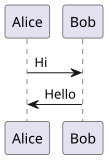

In [27]:
%%plantUML
@startuml
Alice -> Bob: Hi
Bob -> Alice: Hello
@enduml

In [28]:
%%timeit
int s = 0;
for (int i = 0; i < 10000; i++) s += i;
s

samples: [18834565, 18043222, 17486558, 19616153, 19883438]
min=17486558 median=18834565 avg=18772787,20 max=19883438 (nanoseconds)


## Database schema & associations

Use the RDBMS magics to inspect database schemas and render query results as tables directly in the notebook.

Examples below call `rdbmsSchema` to print schema information and `sqlAsTable` to render SQL query results. These magics rely on a configured JDBC `EntityManagerFactory`/connection available in the kernel environment.

In [29]:
%maven com.h2database:h2:2.2.224
// Add H2 in-memory JDBC driver to the runtime classpath so the following setup can run

In [30]:
System.setProperty("jdbc.driver", "org.h2.Driver");
System.setProperty("jdbc.url", "jdbc:h2:mem:demo;DB_CLOSE_DELAY=-1;MODE=PostgreSQL");
try (java.sql.Connection c = java.sql.DriverManager.getConnection(System.getProperty("jdbc.url"))) {
    try (java.sql.Statement st = c.createStatement()) {
        st.execute("CREATE SCHEMA IF NOT EXISTS EX_PRODUCT_ORDER");
        st.execute("CREATE TABLE IF NOT EXISTS EX_PRODUCT_ORDER.PRODUCT (id BIGINT GENERATED BY DEFAULT AS IDENTITY PRIMARY KEY, name VARCHAR(255), price DOUBLE)");
        st.execute("CREATE TABLE IF NOT EXISTS EX_PRODUCT_ORDER.CUSTOMER (id BIGINT GENERATED BY DEFAULT AS IDENTITY PRIMARY KEY, name VARCHAR(255))");
        st.execute("CREATE TABLE IF NOT EXISTS EX_PRODUCT_ORDER.ORDERS (id BIGINT GENERATED BY DEFAULT AS IDENTITY PRIMARY KEY, customer_id BIGINT, order_date TIMESTAMP, FOREIGN KEY (customer_id) REFERENCES EX_PRODUCT_ORDER.CUSTOMER(id))");
        st.execute("CREATE TABLE IF NOT EXISTS EX_PRODUCT_ORDER.ORDER_LINE (id BIGINT GENERATED BY DEFAULT AS IDENTITY PRIMARY KEY, order_id BIGINT, product_id BIGINT, quantity INT, FOREIGN KEY (order_id) REFERENCES EX_PRODUCT_ORDER.ORDERS(id), FOREIGN KEY (product_id) REFERENCES EX_PRODUCT_ORDER.PRODUCT(id))");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.PRODUCT(name, price) VALUES ('Pen', 1.0)");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.PRODUCT(name, price) VALUES ('Paper', 5.0)");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.PRODUCT(name, price) VALUES ('Car', 20000)");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.CUSTOMER(name) VALUES ('Alice')");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.CUSTOMER(name) VALUES ('Bob')");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.ORDERS(customer_id, order_date) VALUES (1, CURRENT_TIMESTAMP())");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.ORDERS(customer_id, order_date) VALUES (2, CURRENT_TIMESTAMP())");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.ORDER_LINE(order_id, product_id, quantity) VALUES (1, 1, 2)");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.ORDER_LINE(order_id, product_id, quantity) VALUES (1, 2, 3)");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.ORDER_LINE(order_id, product_id, quantity) VALUES (2, 3, 1)");
    }
}
System.out.println("H2 in-memory demo DB initialized (jdbc.url=" + System.getProperty("jdbc.url") + ")");

H2 in-memory demo DB initialized (jdbc.url=jdbc:h2:mem:demo;DB_CLOSE_DELAY=-1;MODE=PostgreSQL)


### RDBMS Schema Diagram
Use the `%%rdbmsSchema` cell magic to render the current JDBC schema as a PlantUML diagram. The kernel uses `jdbc.url` (set earlier) to connect to the demo H2 database.

```plantuml
@startuml
left to right direction
skinparam roundcorner 5
skinparam shadowing true
skinparam entity {
    BackgroundColor #EEEEEE
    ArrowColor #2688d4
    BorderColor #2688d4
}
!define primary_key(x) <b><color:#b8861b>PK</color> x</b>
!define foreign_key(x) <color:#aaaaaa>FK</color> x
!define column(x) <color:#efefef>*</color> x
!define table(x) entity x << (T, white) >>

table(CUSTOMER) {
	primary_key(ID) : BIGINT(64)
--
	column(NAME) : CHARACTER VARYING(255)
}
table(ORDERS) {
	primary_key(ID) : BIGINT(64)
--
	foreign_key(CUSTOMER_ID) : BIGINT(64)
	column(ORDER_DATE) : TIMESTAMP(26)
}
table(ORDER_LINE) {
	primary_key(ID) : BIGINT(64)
--
	foreign_key(ORDER_ID) : BIGINT(64)
	foreign_key(PRODUCT_ID) : BIGINT(64)
	column(QUANTITY) : INTEGER(32)
}
table(PRODUCT) {
	primary_key(ID) : BIGINT(64)
--
	column(NAME) : CHARACTER VARYING(255)
	column(PRICE) : DOUBLE PRECISION(53)
}
ORDERS "0..*" --> "1" CUSTOMER : CUSTOMER_ID -> ID
ORDER_LINE "0..*" --> "1" ORDERS : ORDER_ID -> ID
ORDER_LINE "0..*" --> "1" PRODUCT : PRODUCT_ID -> ID
@enduml
```

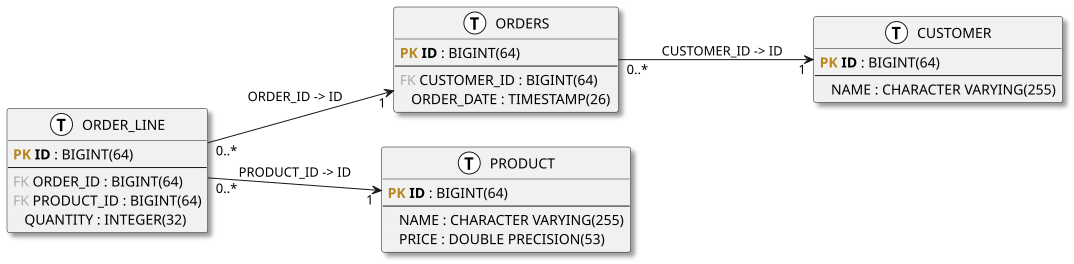

In [31]:
%%rdbmsSchema EX_PRODUCT_ORDER showSource
// leave body empty to include all tables in the schema

**Schema options:**
- `showSource` / `-s` : Display PlantUML source alongside diagram
- `include=TABLE1,TABLE2` : Only include specific tables
- `exclude=TABLE3` : Exclude specific tables
- `scale=1.2` : Scale diagram (default 1.0)
- `handwritten` : Use handwritten style

### SQL Results as HTML Table
Use `%%sqlAsTable` to run a query and render results as an HTML table in the notebook.

In [32]:
%%sqlAsTable
SELECT id, name, price FROM EX_PRODUCT_ORDER.PRODUCT ORDER BY id LIMIT 10 OFFSET 0;

ID,NAME,PRICE
1,Pen,1.0
2,Paper,5.0
3,Car,20000.0


**SQL query options:**
- `--format=html` : HTML table (default)
- `--format=csv` : CSV output for data export
- `--maxRows=N` : Limit result rows
- `--showQuery` : Display the SQL query above results

In [33]:
%%sqlAsTable --format=csv --showQuery
SELECT c.name AS customer, p.name AS product, ol.quantity
FROM EX_PRODUCT_ORDER.ORDERS o
JOIN EX_PRODUCT_ORDER.CUSTOMER c ON o.customer_id = c.id
JOIN EX_PRODUCT_ORDER.ORDER_LINE ol ON ol.order_id = o.id
JOIN EX_PRODUCT_ORDER.PRODUCT p ON ol.product_id = p.id
ORDER BY c.name, p.name;

CUSTOMER,PRODUCT,QUANTITY
Alice,Paper,3
Alice,Pen,2
Bob,Car,1


### PlantUML from File
Create a PlantUML file and render it with `%%plantUMLFile`.

In [34]:
%%write /tmp/sample_schema.puml
@startuml
entity PRODUCT
entity CUSTOMER
PRODUCT ||--o{ ORDER_LINE
@enduml

Write to /tmp/sample_schema.puml success.


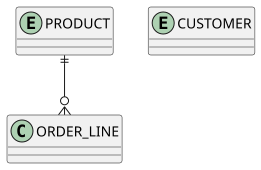

In [35]:
%%plantUMLFile
/tmp/sample_schema.puml

## Sample Java files
The folder docs/notebooks/sample_java contains small example Java sources.
Use `%load` to load a file into a cell, then `%%compile` to compile it. Example workflow:
- Cell 1: `String file = %load sample_java/com/example/Greeter.java;` (assign loaded file contents to a variable)
- Cell 2: `%%compile com.example.Greeter -v` (or run the loaded cell content with `%%compile`)
- Then import and use `com.example.Greeter` in a cell.

In [36]:
String file = %load sample_java/com/example/Greeter.java;
System.out.println(file);

09:23:05.293 [IJava-executor-0] WARN  i.g.s.ijava.magics.MagicsTool -- %load: file not found: sample_java/com/example/Greeter.java; (tried 'sample_java/com/example/Greeter.java;')
null


In [37]:
%%compile com.example.Greeter -v
public class Greeter {
  private final String name;
  public Greeter(String name) { this.name = name; }
  public String greet() { return "Hello " + name; }
}

09:23:05.391 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Compiling com.example.Greeter with debug=false and nowarn=false
09:23:05.392 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Source file prepared at: /var/home/bruno/.jupyter/java-workspace/src/main/java/com/example/Greeter.java
09:23:05.575 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Added to classpath: /var/home/bruno/.jupyter/java-workspace/target/classes
09:23:05.575 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Successfully compiled com.example.Greeter and added to classpath


In [38]:
import com.example.Greeter;
Greeter g = new Greeter("Notebook");
System.out.println(g.greet());

Hello Notebook


## Java source extractors
Quick demos for `%%javasrcList` and `%%javasrcMethodByName`. Use these to inspect local Java files and pick indices for extraction.

In [39]:
%%javasrcList
sample_java/com/example/OrderExample.java

Summary of sample_java/com/example/OrderExample.java

ClassOrInterfaceDeclaration: OrderExample
  - String summary(Product)
  - String deprecatedMethod()



### Java Source Code Extraction

**Available magics:**
- `%%javasrcList` : Lists all classes and methods in a Java file (summary view)
- `%%javasrcMethodByName` : Extract methods by name with regex support
- `%%javasrcClassByName` : Extract entire class by fully qualified name
- `%%javasrcInterfaceByName` : Extract interface by fully qualified name
- `%%javasrcMethodByAnnotationName` : Extract methods by annotation

**Common options:**
- `--help` or `-h` : Show comprehensive usage (available for javasrcMethodByName)
- `--raw` : Plain text output (no Markdown formatting)
- `--fenced` : Markdown fenced code block output
- `--src=PATH` : Specify source root directory
- `selection=INDEX` : Select specific match when multiple found

In [40]:
%%javasrcMethodByName --help
// Placeholder to avoid empty cell issue

**Usage:** `%%javasrcMethodByName [options] <FullyQualifiedClassName|ClassName> [methodName|index]`

**Options:**
- `--src <dir>`: source root to resolve FQCN (e.g., `--src=sample_java`)
- `methodRegex=<regex>`: select methods whose name matches regex
- `selectIndex=<n>` or positional index: pick one when multiple matches
- `--raw` / `--fenced`: output format

**Examples:**
- `%%javasrcMethodByName methodRegex=summary --src=sample_java com.example.OrderExample`
- `%%javasrcMethodByName com.example.OrderExample myMethod`
- `%%javasrcMethodByName selectIndex=1 com.example.OrderExample myMethod`


In [41]:
%%javasrcMethodByName methodRegex=summary --src=sample_java com.example.OrderExample
sample_java/com/example/OrderExample.java

```Java
public static String summary(Product p) {
    return p.id + ":" + p.name + ":" + p.price;
}
```

In [42]:
%%javasrcInterfaceByName --src=sample_java com.example.SayHello
sample_java/com/example/SayHello.java

```Java
public interface SayHello {

    String sayHello(String name);
}
```

In [43]:
%%javasrcMethodByAnnotationName --src=sample_java com.example.OrderExample Deprecated
sample_java/com/example/OrderExample.java

```Java
@Deprecated
public static String deprecatedMethod() {
    return "This method is deprecated";
}
```

### Additional Examples: Source extraction, classpath, reload, compile dry-run, timing, benchmark
These examples demonstrate the newly added magics and options.

In [44]:
%%javasrcConstructorByName --src=sample_java com.example.OrderExample
sample_java/com/example/OrderExample.java

```Java
0: OrderExample()

public OrderExample() {
}


```

In [45]:
%%javasrcFieldByName --src=sample_java com.example.Product
sample_java/com/example/Product.java

```Java
long id (modifiers: private )

private long id;

String name (modifiers: private )

private String name;

double price (modifiers: private )

private double price;


```

In [46]:
%%javasrcFieldByName --src=sample_java com.example.Product name
sample_java/com/example/Product.java

```Java
String name (modifiers: private )

private String name;


```

In [47]:
%%javasrcJavadoc --src=sample_java com.example.Greeter
sample_java/com/example/Greeter.java

A simple Greeter class that greets a person by name.

In [48]:
%%javasrcJavadoc --src=sample_java com.example.Greeter greet
sample_java/com/example/Greeter.java

Greets the person by name.

- @return — A greeting message.

In [49]:
%classpath-snapshot

/var/home/bruno/.local/share/jupyter/kernels/java/IJava-1.4.5.jar (lastModified=2026-01-16T08:22:44Z)



In [50]:
%reload-class com.example.Greeter

Loaded class com.example.Greeter (loader=jdk.jshell.execution.DefaultLoaderDelegate$RemoteClassLoader@c86b9e3)


In [51]:
%%compile com.example.Dummy --dry-run=true
public class Dummy {
  public static int value() { return 42; }
}

Dry run: would compile source file: /var/home/bruno/.jupyter/java-workspace/src/main/java/com/example/Dummy.java
With javac options: -cp file:/var/home/bruno/.m2/repository/org/apache/commons/commons-text/1.10.0/commons-text-1.10.0.jar:file:/var/home/bruno/.m2/repository/org/apache/commons/commons-lang3/3.12.0/commons-lang3-3.12.0.jar:file:/var/home/bruno/.m2/repository/org/projectlombok/lombok/1.18.42/lombok-1.18.42.jar:file:///var/home/bruno/.jupyter/java-workspace/target/classes/:file:/var/home/bruno/.m2/repository/com/google/guava/guava/32.1.3-jre/guava-32.1.3-jre.jar:file:/var/home/bruno/.m2/repository/com/google/guava/failureaccess/1.0.1/failureaccess-1.0.1.jar:file:/var/home/bruno/.m2/repository/com/google/guava/listenablefuture/9999.0-empty-to-avoid-conflict-with-guava/listenablefuture-9999.0-empty-to-avoid-conflict-with-guava.jar:file:/var/home/bruno/.m2/repository/com/google/code/findbugs/jsr305/3.0.2/jsr305-3.0.2.jar:file:/var/home/bruno/.m2/repository/org/checkerframework/c

In [52]:
%%timeit iterations=5 warmup=2
int s = 0;
for (int i = 0; i < 10000; i++) s += i;
s

samples: [20646336, 23860698, 18893042, 19000318, 20836091]
min=18893042 median=20646336 avg=20647297,00 max=23860698 (nanoseconds)


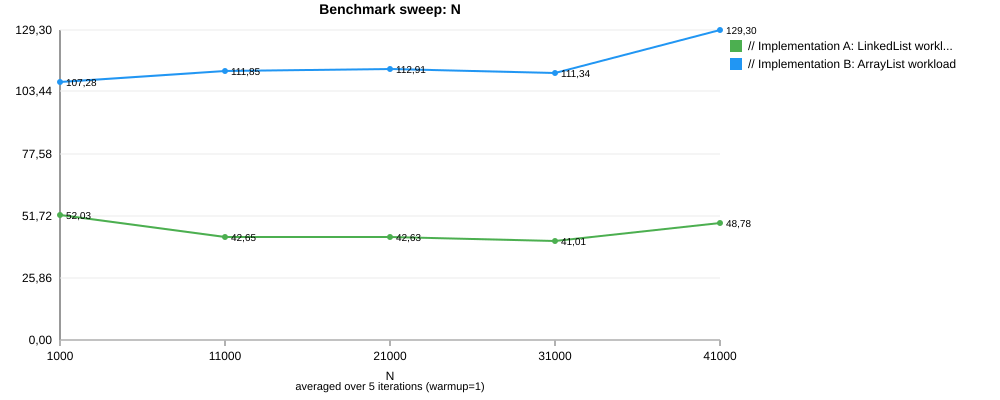

In [53]:
%%benchmark --chart --sweep var=N start=1000 end=50000 step=10000 iterations=5 warmup=1
// Implementation A: LinkedList workload (uses N)
  java.util.LinkedList<Integer> list = new java.util.LinkedList<>();
  for (int i = 0; i < N; i++) list.add(i);
  long sum = 0L;
  for (Integer v : list) sum += v;
  // remove half elements from front to simulate queue-like work
  for (int i = 0; i < N / 2; i++) list.removeFirst();
  sum += list.size();
---
// Implementation B: ArrayList workload
  java.util.ArrayList<Integer> list = new java.util.ArrayList<>();
  int N = 50_000;
  for (int i = 0; i < N; i++) list.add(i);
  long sum = 0L;
  for (Integer v : list) sum += v;
  // remove half elements from front to simulate queue-like work (expensive for ArrayList)
  for (int i = 0; i < N / 2; i++) list.remove(0);
  sum += list.size();

In [54]:
public static class BenchmarkHelpers {
  public static long listTest(java.util.function.Supplier<java.util.List<Integer>> maker, int N) {
    java.util.List<Integer> list = maker.get();
    for (int i = 0; i < N; i++) list.add(i);
    long s = 0L;
    for (Integer v : list) s += v;
    for (int i = 0; i < N / 2; i++) list.remove(0);
    return s + list.size();
  }

  public static long randomOpsTest(java.util.function.Supplier<java.util.List<Integer>> maker, int N, int ops, long seed) {
    java.util.List<Integer> list = maker.get();
    for (int i = 0; i < N; i++) list.add(i);
    java.util.Random rnd = new java.util.Random(seed);
    for (int o = 0; o < ops; o++) {
      if (list.isEmpty()) { list.add(rnd.nextInt(N + ops + 1)); continue; }
      int pos = rnd.nextInt(list.size());
      if (rnd.nextBoolean()) list.add(pos, rnd.nextInt(N + ops + 1));
      else list.remove(pos);
    }
    long s = 0L; for (Integer v : list) s += v;
    return s + list.size();
  }
}

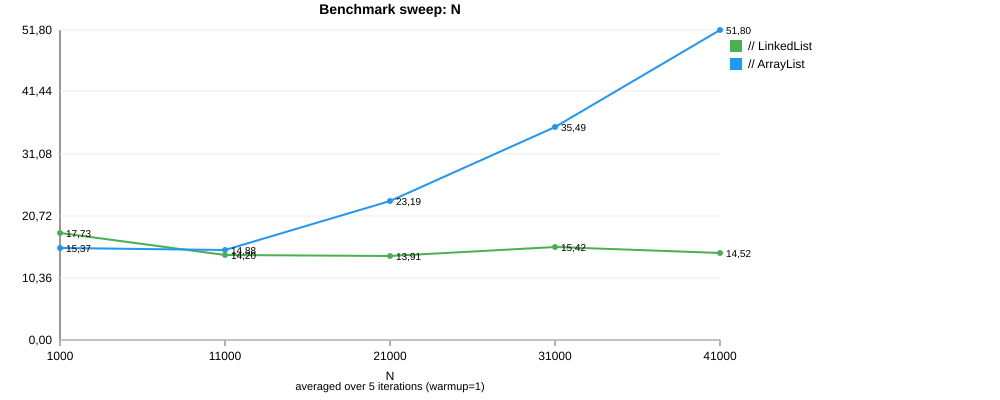

In [55]:
%%benchmark --chart --sweep var=N start=1000 end=50000 step=10000 iterations=5 warmup=1
// LinkedList
BenchmarkHelpers.listTest(() -> new java.util.LinkedList<>(), N);
---
// ArrayList
BenchmarkHelpers.listTest(() -> new java.util.ArrayList<>(), N);

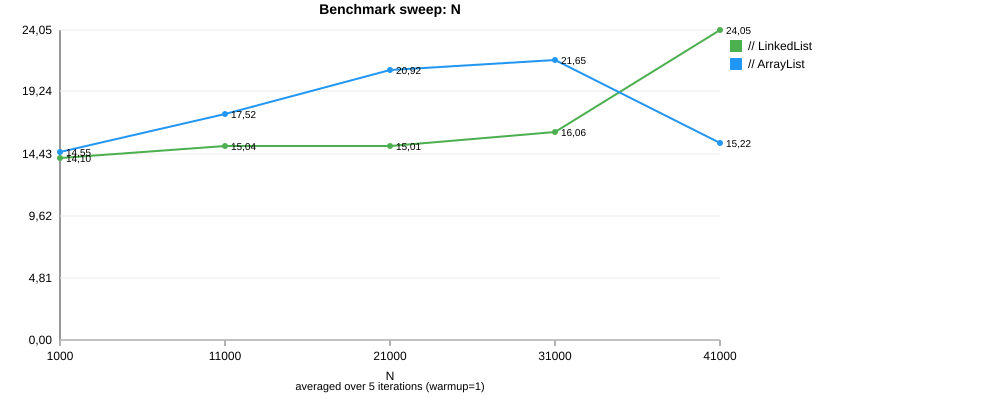

In [56]:
%%benchmark --chart --sweep var=N start=1000 end=50000 step=10000 iterations=5 warmup=1
// LinkedList
BenchmarkHelpers.randomOpsTest(() -> new java.util.LinkedList<>(), N, 1, 1);
---
// ArrayList
BenchmarkHelpers.randomOpsTest(() -> new java.util.ArrayList<>(), N, 1, 1);

### Extract class by name

In [57]:
%%javasrcClassByName --src=sample_java com.example.Greeter
sample_java/com/example/Greeter.java

```Java
public class Greeter {
    private final String name;

    public Greeter(String name) {
        this.name = name;
    }

    /**
     * Greets the person by name.
     * 
     * @return A greeting message.
     */
    public String greet() {
        return "Hello " + name;
    }
}
```

---

## Summary: Getting Help

Almost all magics now support `--help` or `-h` flag for comprehensive documentation:

```java
%%shell --help
%%compile --help
%%javasrcMethodByName --help
%pom --help
```

**Quick reference:**
- `%listMagic` - Show all available line and cell magics
- `%listLineMagic` - Show only line magics
- `%listCellMagic` - Show only cell magics

**Resources:**
- [Magics Documentation](../../magics.md)
- [Magics Audit and Improvement Plan](../../MAGICS_AUDIT_AND_IMPROVEMENT_PLAN.md)
- [Consolidation Summary](../../MAGICS_CONSOLIDATION_SUMMARY.md)

**Next Steps:**
Experiment with the magics, check the help text, and report any issues or feature requests!